# Calculate mAP scores comparing the compounds at an MOA level to the control (DMSO)

In [1]:
import os
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from copairs import map  # noqa: A004
from copairs.matching import assign_reference_index
from plotnine import (
    aes,
    element_text,
    facet_wrap,
    geom_abline,
    geom_bar,
    geom_hline,
    geom_point,
    geom_text,
    ggplot,
    labs,
    scale_color_gradientn,
    scale_fill_manual,
    theme,
    theme_bw,
)
from plotnine.options import set_option
from PyComplexHeatmap import ClusterMapPlotter, HeatmapAnnotation, anno_simple
from scipy.stats import mannwhitneyu


## Helper functions

In [2]:
# Perform mean average precision calculation
def get_mean_average_precision(  # noqa: PLR0913
    activity_df: pd.DataFrame,
    pos_sameby: list,
    pos_diffby: list,
    neg_sameby: list,
    neg_diffby: list,
    seed: int = 0,
) -> pd.DataFrame:
    """Calculate mean average precision for activity data.

    Args:
        activity_df (pd.DataFrame): Activity data.
        pos_sameby (list): Positive samples to compare.
        pos_diffby (list): Positive samples to compare.
        neg_sameby (list): Negative samples to compare.
        neg_diffby (list): Negative samples to compare.
        seed (int, optional): Random seed for reproducibility. Defaults to 0.

    Returns:
        pd.DataFrame: Mean average precision results.
    """
    metadata = activity_df.filter(regex="^Metadata")
    profiles = activity_df.filter(regex="^(?!Metadata)").values

    activity_ap = map.average_precision(
        metadata, profiles, pos_sameby, pos_diffby, neg_sameby, neg_diffby
    )
    activity_ap = activity_ap.query("Metadata_broad_sample != 'DMSO'")

    activity_map = map.mean_average_precision(
        activity_ap, pos_sameby, seed=seed, null_size=10000, threshold=0.05
    )
    activity_map["-log10(p-value)"] = -activity_map["corrected_p_value"].apply(np.log10)
    return activity_map


# Calculate proportion of points above, below, and equal to y=x per dose
def proportion_above_below_y_eq_x(df: pd.DataFrame) -> pd.DataFrame:
    """Calculate the proportion of points above, below, and equal to the y=x line.

    Args:
        df (pd.DataFrame): DataFrame containing the activity data.

    Returns:
        pd.DataFrame: Dataframe with proportions and counts per dose.
    """
    results = []
    for dose, group in df.groupby("Metadata_dose_recode"):
        above = (
            group["mean_average_precision_postQC"]
            > group["mean_average_precision_preQC"]
        ).sum()
        below = (
            group["mean_average_precision_postQC"]
            < group["mean_average_precision_preQC"]
        ).sum()
        equal = (
            group["mean_average_precision_postQC"]
            == group["mean_average_precision_preQC"]
        ).sum()
        total = len(group)
        results.append(
            {
                "Metadata_dose_recode": dose,
                "proportion_above": above / total if total > 0 else np.nan,
                "proportion_below": below / total if total > 0 else np.nan,
                "proportion_equal": equal / total if total > 0 else np.nan,
                "n_points": total,
            }
        )
    return pd.DataFrame(results)


def calculate_replicate_cosine_similarity(
    activity_df: pd.DataFrame,
    group_cols: list[str] | None = None,
    exclude_profile_cols: list[str] | None = None,
    min_replicates: int = 2,
) -> pd.DataFrame:
    """Calculate pairwise replicate cosine similarity for all treatment groups.

    The returned rows are one compound-dose (or general group) each. The mean summarizes all
    pairwise cosine similarities among replicate profiles in that group.

    This function measures within-group reproducibility of feature profiles
    (e.g., compounds, doses, and DMSO controls) by computing cosine similarity
    between replicate feature vectors in a shared feature space.

    Args:
        activity_df (pd.DataFrame): DataFrame containing activity data with metadata and
            profile columns (feature space used for cosine similarity).
        group_cols (list[str], optional): List of metadata columns to group by. Defaults
            to ["Metadata_broad_sample", "Metadata_dose_recode"].
        exclude_profile_cols (list[str], optional): List of numeric columns to exclude
            from profile data (e.g., "failed_proportion").
            Defaults to ["failed_proportion"].
        min_replicates (int, optional): Minimum number of replicates required to
            calculate cosine similarity. Defaults to 2.

    Returns:
        pd.DataFrame: DataFrame with group columns and summary statistics of
            pairwise cosine similarity for each treatment group.
    """
    # Set default columns if not provided
    if group_cols is None:
        group_cols = ["Metadata_broad_sample", "Metadata_dose_recode"]
    if exclude_profile_cols is None:
        exclude_profile_cols = ["failed_proportion"]

    # Use full dataset (no external filtering / map restriction)
    activity_subset = activity_df.copy()

    # Identify profile columns by excluding metadata and specified columns
    metadata_cols = activity_subset.filter(regex="^Metadata").columns
    numeric_cols = activity_subset.select_dtypes(include="number").columns
    profile_cols = [
        col
        for col in numeric_cols
        if col not in metadata_cols and col not in exclude_profile_cols
    ]

    # Calculate pairwise cosine similarity for each group and store results
    results = []
    for group_values, group_df in activity_subset.groupby(group_cols, dropna=False):
        if not isinstance(group_values, tuple):
            group_values = (group_values,)

        # Extract profile data and handle NaN values by replacing them with zeros
        profiles = group_df[profile_cols].to_numpy(dtype=float)
        profiles = np.nan_to_num(profiles, nan=0.0, posinf=0.0, neginf=0.0)

        # Skip groups with fewer than the minimum number of replicates
        if profiles.shape[0] < min_replicates:
            continue

        # Ensure proper cosine similarity even if upstream normalization drifted
        norms = np.linalg.norm(profiles, axis=1, keepdims=True)
        profiles = np.divide(
            profiles, norms, out=np.zeros_like(profiles), where=norms != 0
        )

        cosine_matrix = profiles @ profiles.T

        # Extract upper triangle (excluding diagonal)
        pair_indices = np.triu_indices(profiles.shape[0], k=1)
        pairwise_cosine = cosine_matrix[pair_indices]

        # Store results with group values and summary statistics
        results.append(
            {
                **dict(zip(group_cols, group_values, strict=True)),
                "n_replicates": profiles.shape[0],
                "n_pairwise_comparisons": pairwise_cosine.size,
                "mean_pairwise_cosine_similarity": pairwise_cosine.mean(),
                "median_pairwise_cosine_similarity": np.median(pairwise_cosine),
                "std_pairwise_cosine_similarity": (
                    pairwise_cosine.std(ddof=1) if pairwise_cosine.size > 1 else 0.0
                ),
            }
        )

    return pd.DataFrame(results)


## Load in the data for pre and post QC

In [3]:
MIN_REPLICATES = 2  # Minimum number of replicates required

# Input path for single-cell profiles
input_dir = pathlib.Path(
    "/home/jenna/mnt/bandicoot/LINCS_data/processed_profiles/single_cell_profiles"
)

# Output path for merged profiles
output_dir = pathlib.Path("./mAP_results")
output_dir.mkdir(parents=True, exist_ok=True)

# Load cell painting profiles (pre-QC)
pre_qc_file = pathlib.Path(input_dir, "whole_batch_pre_qc_cpd_replicates.parquet")
pre_qc_df = pd.read_parquet(pre_qc_file)
pre_qc_df = pre_qc_df.drop(columns=["broad_id", "pert_iname", "moa", "replicate_name"])

# Load cell painting profiles (post-QC)
post_qc_file = pathlib.Path(input_dir, "whole_batch_post_qc_cpd_replicates.parquet")
post_qc_df = pd.read_parquet(post_qc_file)
post_qc_df = post_qc_df.drop(
    columns=["broad_id", "pert_iname", "moa", "replicate_name"]
)
post_qc_df["Metadata_sc_count_failed_qc"] = post_qc_df[
    "Metadata_sc_count_failed_qc"
].fillna(0)

# Align "Metadata_sc_count_failed_qc" from post-QC df to pre-QC df using
# Metadata_Plate and Metadata_Well
pre_qc_df = pre_qc_df.merge(
    post_qc_df[["Metadata_Plate", "Metadata_Well", "Metadata_sc_count_failed_qc"]],
    on=["Metadata_Plate", "Metadata_Well"],
    how="left",
    suffixes=("", "_postqc"),
)
pre_qc_df["Metadata_sc_count_failed_qc"] = pre_qc_df[
    "Metadata_sc_count_failed_qc"
].fillna(0)


In [4]:
# Compute percentage of failed QC single-cell across all plates in post_qc_df
total_failed = post_qc_df["Metadata_sc_count_failed_qc"].sum()
total_cells = post_qc_df["Metadata_sc_count"].sum()
failed_qc_percentage = (total_failed / total_cells) * 100
print(
    f"Percentage of failed QC single-cell across all plates: "
    f"{failed_qc_percentage:.2f}%"
)


Percentage of failed QC single-cell across all plates: 29.03%


In [5]:
# Calculate proportion of failed cells for each well
post_qc_df["failed_proportion"] = post_qc_df["Metadata_sc_count_failed_qc"] / (
    post_qc_df["Metadata_sc_count_failed_qc"]
    + post_qc_df["Metadata_sc_count_passed_qc"]
)

# Compare failed proportions between compounds and DMSO
compound_failed = post_qc_df.loc[
    post_qc_df["Metadata_broad_sample"] != "DMSO", "failed_proportion"
]
dmso_failed = post_qc_df.loc[
    post_qc_df["Metadata_broad_sample"] == "DMSO", "failed_proportion"
]

# Print mean failed proportions
print(f"Mean failed proportion (compounds): {compound_failed.mean():.4f}")
print(f"Mean failed proportion (DMSO): {dmso_failed.mean():.4f}")


Mean failed proportion (compounds): 0.3019
Mean failed proportion (DMSO): 0.2970


## Assign reference index

In [6]:
reference_col = "Metadata_reference_index"

pre_qc_df_activity = assign_reference_index(
    pre_qc_df,
    "Metadata_broad_sample == 'DMSO'",  # condition to get reference profiles
    reference_col=reference_col,
    default_value=-1,
)

post_qc_df_activity = assign_reference_index(
    post_qc_df,
    "Metadata_broad_sample == 'DMSO'",  # condition to get reference profiles
    reference_col=reference_col,
    default_value=-1,
)


## Set positive and negative pairs for compounds

In [7]:
# positive pairs are replicates of the same treatment
pos_sameby = ["Metadata_broad_sample", "Metadata_dose_recode", reference_col]
pos_diffby = ["Metadata_Plate"]

# negative pairs are replicates of different treatments
neg_sameby = []  # set plate if you don't want to compare controls across all plates
neg_diffby = ["Metadata_broad_sample", reference_col]


## Calculate mAP scores per treatment compared to controls for both pre- and post-QC

### Pre-QC dataframe

In [8]:
preqc_map_file = f"{output_dir}/final_map_scores_preQC.parquet"
if os.path.exists(preqc_map_file):
    final_map_preQC = pd.read_parquet(preqc_map_file)
    print("Loaded preQC mAP results from file.")
else:
    list_of_dfs_map_preQC = []
    for treatment in pre_qc_df_activity["Metadata_broad_sample"].unique():
        if treatment == "DMSO":
            continue
        treatment_plates = pre_qc_df_activity.loc[
            pre_qc_df_activity["Metadata_broad_sample"] == treatment, "Metadata_Plate"
        ].unique()
        treatment_df = pre_qc_df_activity[
            (
                (pre_qc_df_activity["Metadata_broad_sample"] == treatment)
                | (pre_qc_df_activity["Metadata_broad_sample"] == "DMSO")
            )
            & (pre_qc_df_activity["Metadata_Plate"].isin(treatment_plates))
        ]
        # Check if there are at least two replicates for positive pairing
        n_replicates = treatment_df[
            treatment_df["Metadata_broad_sample"] == treatment
        ].shape[0]
        unique_pos_diffby = treatment_df[
            treatment_df["Metadata_broad_sample"] == treatment
        ][pos_diffby].drop_duplicates()
        if n_replicates < MIN_REPLICATES or unique_pos_diffby.shape[0] < MIN_REPLICATES:
            print(
                f"Skipping treatment {treatment}: not enough replicates or "
                f"not enough unique '{pos_diffby}' values for positive pairs."
            )
            continue
        # Calculate average proportion of failed single cells per dose
        failed_cells = (
            treatment_df[treatment_df["Metadata_broad_sample"] == treatment]
            .assign(
                Metadata_failed_prop=lambda x: (
                    x["Metadata_sc_count_failed_qc"] / x["Metadata_sc_count"]
                )
            )
            .groupby("Metadata_dose_recode")["Metadata_failed_prop"]
            .mean()
        )
        # Perform mAP calculation per treatment (use defaults)
        treatment_map = get_mean_average_precision(
            treatment_df, pos_sameby, pos_diffby, neg_sameby, neg_diffby
        )
        # Map average failed cells to treatment_map
        treatment_map["Metadata_avg_prop_failed_single_cells"] = treatment_map[
            "Metadata_dose_recode"
        ].map(failed_cells)
        list_of_dfs_map_preQC.append(treatment_map)

    # Concatenate all treatment mAP results
    final_map_preQC = pd.concat(list_of_dfs_map_preQC, ignore_index=True)
    final_map_preQC["QC_status"] = "pre-QC"
    # Save final mAP results to file
    final_map_preQC.to_parquet(preqc_map_file, index=False)


Loaded preQC mAP results from file.


### Post-QC dataframe

In [9]:
postqc_map_file = f"{output_dir}/final_map_scores_postQC.parquet"
if os.path.exists(postqc_map_file):
    final_map_postQC = pd.read_parquet(postqc_map_file)
    print("Loaded postQC mAP results from file.")
else:
    list_of_dfs_map_postQC = []
    for treatment in post_qc_df_activity["Metadata_broad_sample"].unique():
        if treatment == "DMSO":
            continue
        treatment_plates = post_qc_df_activity.loc[
            post_qc_df_activity["Metadata_broad_sample"] == treatment, "Metadata_Plate"
        ].unique()
        treatment_df = post_qc_df_activity[
            (
                (post_qc_df_activity["Metadata_broad_sample"] == treatment)
                | (post_qc_df_activity["Metadata_broad_sample"] == "DMSO")
            )
            & (post_qc_df_activity["Metadata_Plate"].isin(treatment_plates))
        ]
        # Check if there are at least two replicates for positive pairing
        n_replicates = treatment_df[
            treatment_df["Metadata_broad_sample"] == treatment
        ].shape[0]
        unique_pos_diffby = treatment_df[
            treatment_df["Metadata_broad_sample"] == treatment
        ][pos_diffby].drop_duplicates()
        if n_replicates < MIN_REPLICATES or unique_pos_diffby.shape[0] < MIN_REPLICATES:
            print(
                f"Skipping treatment {treatment}: not enough replicates or "
                f"not enough unique '{pos_diffby}' values for positive pairs."
            )
            continue
        # Calculate average proportion of failed single cells per dose
        failed_cells = (
            treatment_df[treatment_df["Metadata_broad_sample"] == treatment]
            .assign(
                Metadata_failed_prop=lambda x: (
                    x["Metadata_sc_count_failed_qc"] / x["Metadata_sc_count"]
                )
            )
            .groupby("Metadata_dose_recode")["Metadata_failed_prop"]
            .mean()
        )
        # Perform mAP calculation per treatment (use defaults)
        treatment_map = get_mean_average_precision(
            treatment_df, pos_sameby, pos_diffby, neg_sameby, neg_diffby
        )
        # Map average failed cells to treatment_map
        treatment_map["Metadata_avg_prop_failed_single_cells"] = treatment_map[
            "Metadata_dose_recode"
        ].map(failed_cells)
        list_of_dfs_map_postQC.append(treatment_map)

    # Concatenate all treatment mAP results
    final_map_postQC = pd.concat(list_of_dfs_map_postQC, ignore_index=True)
    final_map_postQC["QC_status"] = "post-QC"
    # Save final mAP results to file
    final_map_postQC.to_parquet(postqc_map_file, index=False)


Loaded postQC mAP results from file.


## Merge pre-QC and post-QC results

In [10]:
# Merge preQC and postQC results on sample and dose
merged_map = pd.merge(
    final_map_preQC,
    final_map_postQC,
    on=["Metadata_broad_sample", "Metadata_dose_recode"],
    suffixes=("_preQC", "_postQC"),
)

# Compute change per row
merged_map["mAP_change"] = (
    merged_map["mean_average_precision_postQC"]
    - merged_map["mean_average_precision_preQC"]
)

# Filter rows where the preQC was low and the change was large
improved_rows = merged_map.query(
    "mean_average_precision_preQC <= 0.5 and mAP_change >= 0.2"
)

# Count unique compounds
num_improved = improved_rows["Metadata_broad_sample"].nunique()

# Compute percentage of all rows (compounds and doses) that improved
percent_improved = len(improved_rows) / len(merged_map) * 100

print(f"{num_improved} compounds with preQC ≤ 0.5 and an increase ≥ 0.2.")
print(f"These rows represent {percent_improved:.1f}% of all compounds/doses.")


20 compounds with preQC ≤ 0.5 and an increase ≥ 0.2.
These rows represent 0.2% of all compounds/doses.


In [11]:
merged_map


,Metadata_broad_sample,Metadata_dose_recode,Metadata_reference_index_preQC,mean_average_precision_preQC,indices_preQC,p_value_preQC,corrected_p_value_preQC,below_p_preQC,below_corrected_p_preQC,-log10(p-value)_preQC,...,mean_average_precision_postQC,indices_postQC,p_value_postQC,corrected_p_value_postQC,below_p_postQC,below_corrected_p_postQC,-log10(p-value)_postQC,Metadata_avg_prop_failed_single_cells_postQC,QC_status_postQC,mAP_change
0,BRD-A00147595-001-01-5,1,-1,0.062555,"[5, 11, 17, 23]",0.325467,0.325467,False,False,0.487492,...,0.073412,"[5, 11, 17, 23]",0.260274,0.332847,False,False,0.477756,0.246434,post-QC,0.010858
1,BRD-A00147595-001-01-5,2,-1,0.119688,"[4, 10, 16, 22]",0.127087,0.254175,False,False,0.594868,...,0.070067,"[4, 10, 16, 22]",0.277372,0.332847,False,False,0.477756,0.283612,post-QC,-0.049621
2,BRD-A00147595-001-01-5,3,-1,0.093092,"[3, 9, 15, 21]",0.180382,0.270573,False,False,0.567716,...,0.115398,"[3, 9, 15, 21]",0.133687,0.267373,False,False,0.572882,0.284254,post-QC,0.022306
3,BRD-A00147595-001-01-5,4,-1,0.066563,"[2, 8, 14, 20]",0.300470,0.325467,False,False,0.487492,...,0.047250,"[2, 8, 14, 20]",0.479652,0.479652,False,False,0.319074,0.272083,post-QC,-0.019313
4,BRD-A00147595-001-01-5,5,-1,0.366605,"[1, 7, 13, 19]",0.020498,0.061494,True,False,1.211168,...,0.345469,"[1, 7, 13, 19]",0.035196,0.105589,True,False,0.976380,0.259502,post-QC,-0.021136
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9320,BRD-M89827113-001-01-5,2,-1,0.081943,"[4, 10, 16, 22, 28]",0.199880,0.299820,False,False,0.523139,...,0.077720,"[4, 10, 16, 22, 28]",0.216078,0.324118,False,False,0.489297,0.299172,post-QC,-0.004222
9321,BRD-M89827113-001-01-5,3,-1,0.047707,"[3, 9, 15, 21, 27]",0.476752,0.476752,False,False,0.321707,...,0.061417,"[3, 9, 15, 21, 27]",0.317468,0.380962,False,False,0.419118,0.299758,post-QC,0.013709
9322,BRD-M89827113-001-01-5,4,-1,0.097876,"[2, 8, 14, 20, 26]",0.150985,0.299820,False,False,0.523139,...,0.080357,"[2, 8, 14, 20, 26]",0.205979,0.324118,False,False,0.489297,0.296504,post-QC,-0.017519
9323,BRD-M89827113-001-01-5,5,-1,0.082582,"[1, 7, 13, 19, 25]",0.197880,0.299820,False,False,0.523139,...,0.079130,"[1, 7, 13, 19, 25]",0.210679,0.324118,False,False,0.489297,0.291606,post-QC,-0.003452


## Generate plot of mAP scores pre= and post-QC

/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 14 x 4 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/mAP_preQC_vs_postQC_by_dose.png


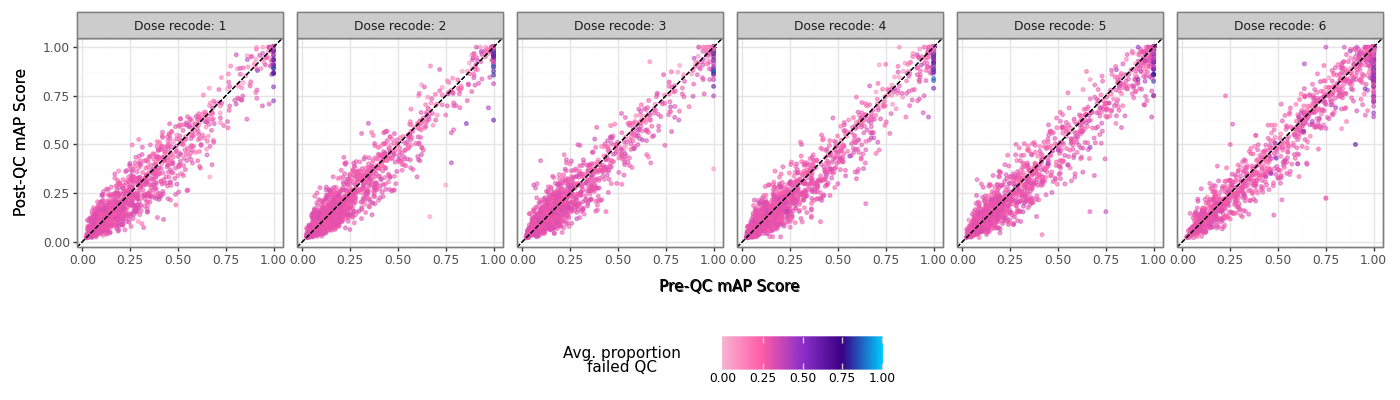

In [12]:
# Drop dose 0 and 7 due to small number of samples
merged_map = merged_map.query("Metadata_dose_recode not in [0, 7]")

# Set the figure size
height = 4
width = 14
set_option("figure_size", (width, height))

# Define the custom coSMic QC palette (lighter pink to purple to cyan)
cosmicqc_palette = [
    "#f8b3d3",  # Light pink
    "#ff5ca7",  # Vibrant pink
    "#8f30c9",  # Medium purple
    "#3b0085",  # Deep purple
    "#00cafd",  # Cyan accent
]

# Make the plotnine plot
p = (
    ggplot(
        merged_map,
        aes(
            x="mean_average_precision_preQC",
            y="mean_average_precision_postQC",
            color="Metadata_avg_prop_failed_single_cells_postQC", # pre-QC and post-QC are the same
        ),
    )
    + geom_point(alpha=0.3, size=1.0)
    + geom_abline(slope=1, intercept=0, linetype="dashed", color="black", size=0.5)
    + facet_wrap(
        "~Metadata_dose_recode", nrow=1, labeller=lambda x: f"Dose recode: {x}"
    )
    + scale_color_gradientn(
        name="Avg. proportion\nfailed QC",
        colors=cosmicqc_palette,
        limits=(0, 1),
    )
    + labs(
        x="Pre-QC mAP Score",
        y="Post-QC mAP Score",
    )
    + theme_bw()
    + theme(
        legend_position="bottom",
    )
)

# Save as PNG
p.save("figures/mAP_preQC_vs_postQC_by_dose.png", dpi=400)
fig = p.draw()

for ax in fig.axes:
    # rasterize scatter points only
    for coll in ax.collections:
        coll.set_rasterized(True)
    # keep lines and legend as vectors

# Save as SVG
fig.savefig("figures/mAP_preQC_vs_postQC_by_dose.svg", dpi=400)

# To show the plot:
p.show()


# Determine the proportion above and below the line

In [13]:
# Get proportion of points above and below y=x line
proportion_df = proportion_above_below_y_eq_x(merged_map)
proportion_df


,Metadata_dose_recode,proportion_above,proportion_below,proportion_equal,n_points
0,1,0.422508,0.529904,0.047588,1555
1,2,0.417363,0.520257,0.062379,1555
2,3,0.408360,0.495177,0.096463,1555
3,4,0.346624,0.533119,0.120257,1555
4,5,0.344093,0.535184,0.120723,1549
5,6,0.262783,0.506149,0.231068,1545


## Calculate average cosine similarity across well-replicates per compound and dose

In [14]:
# Compute replicate cosine similarity for pre-QC and post-QC datasets
replicate_cosine_preQC = calculate_replicate_cosine_similarity(
    pre_qc_df_activity
).add_suffix("_preQC")

replicate_cosine_postQC = calculate_replicate_cosine_similarity(
    post_qc_df_activity
).add_suffix("_postQC")

# Output replicate cosine similarity results to file
replicate_cosine_preQC.to_parquet(
    output_dir / "replicate_pairwise_cosine_similarity_preQC.parquet",
    index=False,
)

replicate_cosine_postQC.to_parquet(
    output_dir / "replicate_pairwise_cosine_similarity_postQC.parquet",
    index=False,
)

# Align pre vs post QC by treatment group
replicate_cosine_df = (
    pd.merge(
        replicate_cosine_preQC,
        replicate_cosine_postQC,
        left_on=["Metadata_broad_sample_preQC", "Metadata_dose_recode_preQC"],
        right_on=["Metadata_broad_sample_postQC", "Metadata_dose_recode_postQC"],
        how="inner",
    )
    .rename(
        columns={
            "Metadata_broad_sample_preQC": "Metadata_broad_sample",
            "Metadata_dose_recode_preQC": "Metadata_dose_recode",
        }
    )
    .drop(columns=["Metadata_broad_sample_postQC", "Metadata_dose_recode_postQC"])
)

# Compute change in replicate similarity (QC effect)
replicate_cosine_df["mean_pairwise_cosine_similarity_change"] = (
    replicate_cosine_df["mean_pairwise_cosine_similarity_postQC"]
    - replicate_cosine_df["mean_pairwise_cosine_similarity_preQC"]
)

# Attach cosine results with mAP results
merged_map_with_cosine = replicate_cosine_df.merge(
    merged_map,
    on=["Metadata_broad_sample", "Metadata_dose_recode"],
    how="inner",
)


In [15]:
merged_map_with_cosine[
    [
        "mean_average_precision_preQC",
        "mean_average_precision_postQC",
        "mean_pairwise_cosine_similarity_change",
    ]
].head(20)


,mean_average_precision_preQC,mean_average_precision_postQC,mean_pairwise_cosine_similarity_change
0,0.062555,0.073412,-0.004114
1,0.119688,0.070067,-0.037913
2,0.093092,0.115398,-0.016334
3,0.066563,0.047250,-0.013036
4,0.366605,0.345469,-0.012678
5,0.507566,0.483001,-0.034752
6,0.350872,0.352945,-0.007562
7,0.403764,0.376187,-0.022106
8,0.268570,0.366320,0.014636
9,0.234350,0.238617,0.002112


## Map the mAP scores to the mean cosine similarity scores

In [16]:
# Add single-cell counts to merged map for analysis of mAP change vs cell count
merged_map_cosine_sc_counts = merged_map_with_cosine.merge(
    post_qc_df[
        [
            "Metadata_broad_sample",
            "Metadata_dose_recode",
            "Metadata_sc_count",
            "Metadata_sc_count_passed_qc",
        ]
    ],
    on=["Metadata_broad_sample", "Metadata_dose_recode"],
    how="left",
)

# Add mAP change column
merged_map_cosine_sc_counts["mAP_change"] = (
    merged_map_cosine_sc_counts["mean_average_precision_postQC"]
    - merged_map_cosine_sc_counts["mean_average_precision_preQC"]
)

# Save the merged mAP with cosine similarity and single-cell counts to a parquet file
merged_map_cosine_sc_counts.to_parquet(
    output_dir / "merged_map_with_cosine_and_sc_counts.parquet", index=False
)


In [17]:
merged_map_cosine_sc_counts["mAP_direction"] = np.where(
    merged_map_cosine_sc_counts["mAP_change"] > 0, "Increased", "Decreased"
)

increased = merged_map_cosine_sc_counts.loc[
    merged_map_cosine_sc_counts["mAP_direction"] == "Increased",
    "mean_pairwise_cosine_similarity_change",
]
decreased = merged_map_cosine_sc_counts.loc[
    merged_map_cosine_sc_counts["mAP_direction"] == "Decreased",
    "mean_pairwise_cosine_similarity_change",
]
stat, p = mannwhitneyu(increased, decreased, alternative="two-sided")
print(f"mean increased: {increased.mean():.4f}, mean decreased: {decreased.mean():.4f}")
print(f"Mann-Whitney U p-value: {p:.11e}")


mean increased: 0.0016, mean decreased: -0.0339
Mann-Whitney U p-value: 0.00000000000e+00


## Plot mAP ranks

/tmp/ipykernel_2164964/2402102647.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/tmp/ipykernel_2164964/2402102647.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 14 x 4 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-package

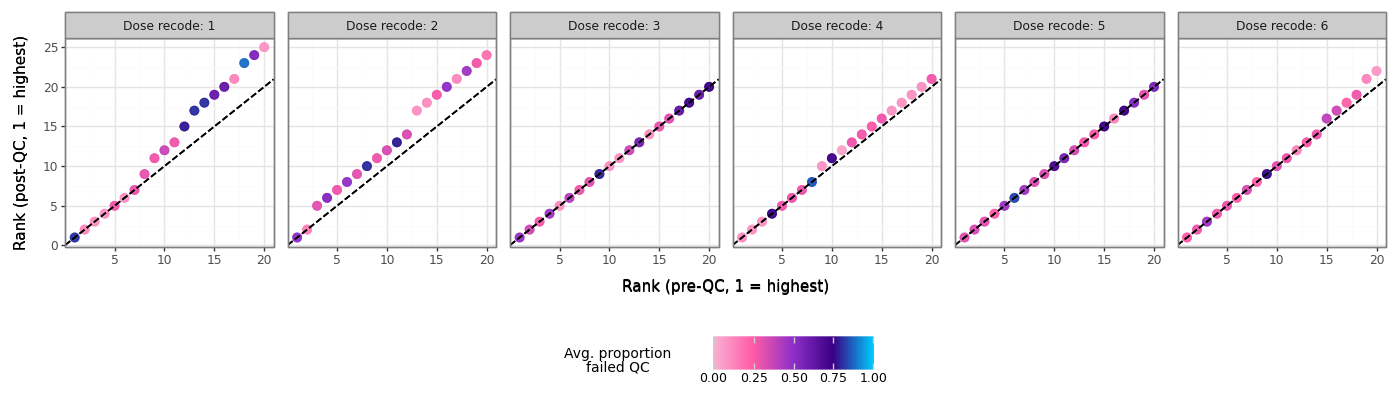

In [18]:
# Rank independently within each dose based on post-QC mAP
merged_map_sorted = merged_map.groupby("Metadata_dose_recode", group_keys=False).apply(
    lambda df: df.sort_values("mean_average_precision_postQC", ascending=False).assign(
        postQC_rank=lambda d: np.arange(1, len(d) + 1)
    )
)

# Rank independently within each dose  each dose based on pre-QC mAP
merged_map_sorted["preQC_rank"] = merged_map_sorted.groupby("Metadata_dose_recode")[
    "mean_average_precision_preQC"
].rank(ascending=False, method="first")

# Keep top 20 compounds per dose based on preQC ranking
merged_map_top = (
    merged_map_sorted.groupby("Metadata_dose_recode", group_keys=False)
    .apply(lambda df: df.nsmallest(20, "preQC_rank"))
    .copy()
)

# Use the custom palette
p = (
    ggplot(
        merged_map_top,
        aes(
            x="preQC_rank",
            y="postQC_rank",
            color="Metadata_avg_prop_failed_single_cells_postQC",
        ),
    )
    + geom_point(size=3, alpha=0.8)
    + geom_abline(intercept=0, slope=1, linetype="--", color="black", size=0.7)
    + scale_color_gradientn(
        name="Avg. proportion\nfailed QC",
        colors=cosmicqc_palette,
        limits=(0, 1),
    )
    + labs(
        x="Rank (pre-QC, 1 = highest)",
        y="Rank (post-QC, 1 = highest)",
        color="Avg prop failed cells",
    )
    + facet_wrap(
        "~Metadata_dose_recode",
        nrow=1,
        labeller=lambda x: f"Dose recode: {x}",
    )
    + theme_bw()
    + theme(
        figure_size=(14, 4),
        legend_position="bottom",
        legend_title=element_text(size=10),
        legend_text=element_text(size=9),
    )
)

# Save plots
p.save("figures/rank_mAP_preQC_vs_postQC_by_dose.png", dpi=400)
fig = p.draw()

for ax in fig.axes:
    for coll in ax.collections:
        coll.set_rasterized(True)

fig.savefig("figures/rank_mAP_preQC_vs_postQC_by_dose.svg", dpi=400)

p.show()


# Sort by ranks pre- and post-QC

In [19]:
# Print for dose recode 1 the sample, and ranks pre and post QC
merged_map_sorted.loc[
    merged_map_sorted["Metadata_dose_recode"] == 4,  # noqa: PLR2004
    [
        "Metadata_broad_sample",
        "preQC_rank",
        "postQC_rank",
    ],
].sort_values("postQC_rank").head(10)


,Metadata_broad_sample,preQC_rank,postQC_rank
9172,BRD-K97963946-001-01-3,1.0,1
171,BRD-A07704283-001-01-3,2.0,2
165,BRD-A07563059-035-01-3,3.0,3
135,BRD-A05821830-341-01-5,4.0,4
2629,BRD-K08248804-001-01-8,5.0,5
2659,BRD-K08799216-001-05-3,6.0,6
2689,BRD-K09078998-001-01-4,7.0,7
2503,BRD-K06858286-001-01-3,8.0,8
2557,BRD-K07310275-001-02-5,273.0,9
2587,BRD-K07798980-001-01-9,9.0,10


## Find top 20 compounds pre- and post-QC and find rescued compounds

In [20]:
# Step 1: Identify top 20 per dose
top20_pre = merged_map_sorted.groupby("Metadata_dose_recode", group_keys=False).apply(
    lambda df: df.nsmallest(20, "preQC_rank")
)[["Metadata_broad_sample", "Metadata_dose_recode", "preQC_rank"]]

top20_post = merged_map_sorted.groupby("Metadata_dose_recode", group_keys=False).apply(
    lambda df: df.nsmallest(20, "postQC_rank")
)[["Metadata_broad_sample", "Metadata_dose_recode", "postQC_rank"]]

# Step 2: Union of compounds
rank_change = pd.merge(
    top20_pre,
    top20_post,
    on=["Metadata_broad_sample", "Metadata_dose_recode"],
    how="outer",
)

# Add back Metadata_moa from post_qc_df_activity
moa_info = post_qc_df_activity[
    ["Metadata_broad_sample", "Metadata_moa"]
].drop_duplicates()
rank_change = rank_change.merge(
    moa_info, on="Metadata_broad_sample", how="left"
)

# Step 3: Attach full dataset ranks (ensures clean columns)
rank_change = pd.merge(
    rank_change,
    merged_map_sorted[
        ["Metadata_broad_sample", "Metadata_dose_recode", "preQC_rank", "postQC_rank"]
    ],
    on=["Metadata_broad_sample", "Metadata_dose_recode"],
    how="left",
    suffixes=("_top20", "")
)

# Enforce clean rank columns (avoid suffix confusion)
rank_change["preQC_rank"] = rank_change["preQC_rank"].fillna(rank_change["preQC_rank_top20"])
rank_change["postQC_rank"] = rank_change["postQC_rank"].fillna(rank_change["postQC_rank_top20"])

# Drop helper columns
rank_change = rank_change.drop(columns=[c for c in rank_change.columns if "_top20" in c])

# Step 4: Keep ONLY compounds present in BOTH pre and post top 20
rank_change = rank_change.dropna(subset=["preQC_rank", "postQC_rank"])

# Step 5: Compute rank differences (pre - post → positive = improved)
rank_change["rank_diff"] = rank_change["preQC_rank"] - rank_change["postQC_rank"]

# Step 6: Define color (no gray category)
def get_color(r: pd.Series) -> str:
    return "blue" if r["rank_diff"] > 0 else "red"

rank_change["color"] = rank_change.apply(get_color, axis=1)

# Step 7: Order compounds per dose for plotting
rank_change["sort_rank"] = rank_change["preQC_rank"]
rank_change = rank_change.sort_values(["Metadata_dose_recode", "sort_rank"])
print(rank_change.shape)
rank_change.head(10)


(131, 8)


/tmp/ipykernel_2164964/1161086498.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/tmp/ipykernel_2164964/1161086498.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


,Metadata_broad_sample,Metadata_dose_recode,Metadata_moa,preQC_rank,postQC_rank,rank_diff,color,sort_rank
3,BRD-A05821830-341-01-5,1,tubulin polymerization inhibitor,1.0,1,0.0,red,1.0
96,BRD-K59317601-001-05-5,1,mTOR inhibitor,2.0,2,0.0,red,2.0
97,BRD-K62737565-003-02-6,1,calcium channel blocker,3.0,3,0.0,red,3.0
99,BRD-K66876909-001-12-6,1,bacterial 50S ribosomal subunit inhibitor,4.0,4,0.0,red,4.0
23,BRD-A88138582-001-04-8,1,glucocorticoid receptor agonist,5.0,5,0.0,red,5.0
18,BRD-A15435692-003-02-3,1,sigma receptor antagonist,6.0,6,0.0,red,6.0
95,BRD-K58550667-001-08-7,1,niacinamide phosphoribosyltransferase inhibitor,7.0,7,0.0,red,7.0
82,BRD-K22848513-001-01-9,1,nuclear factor erythroid derived|like (NRF2) a...,8.0,9,-1.0,red,8.0
85,BRD-K31627533-001-09-5,1,glucocorticoid receptor agonist,9.0,11,-2.0,red,9.0
94,BRD-K56957086-001-06-3,1,HDAC inhibitor,10.0,12,-2.0,red,10.0


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 14 x 6 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/rank_change_dose_1_bar_plot.png


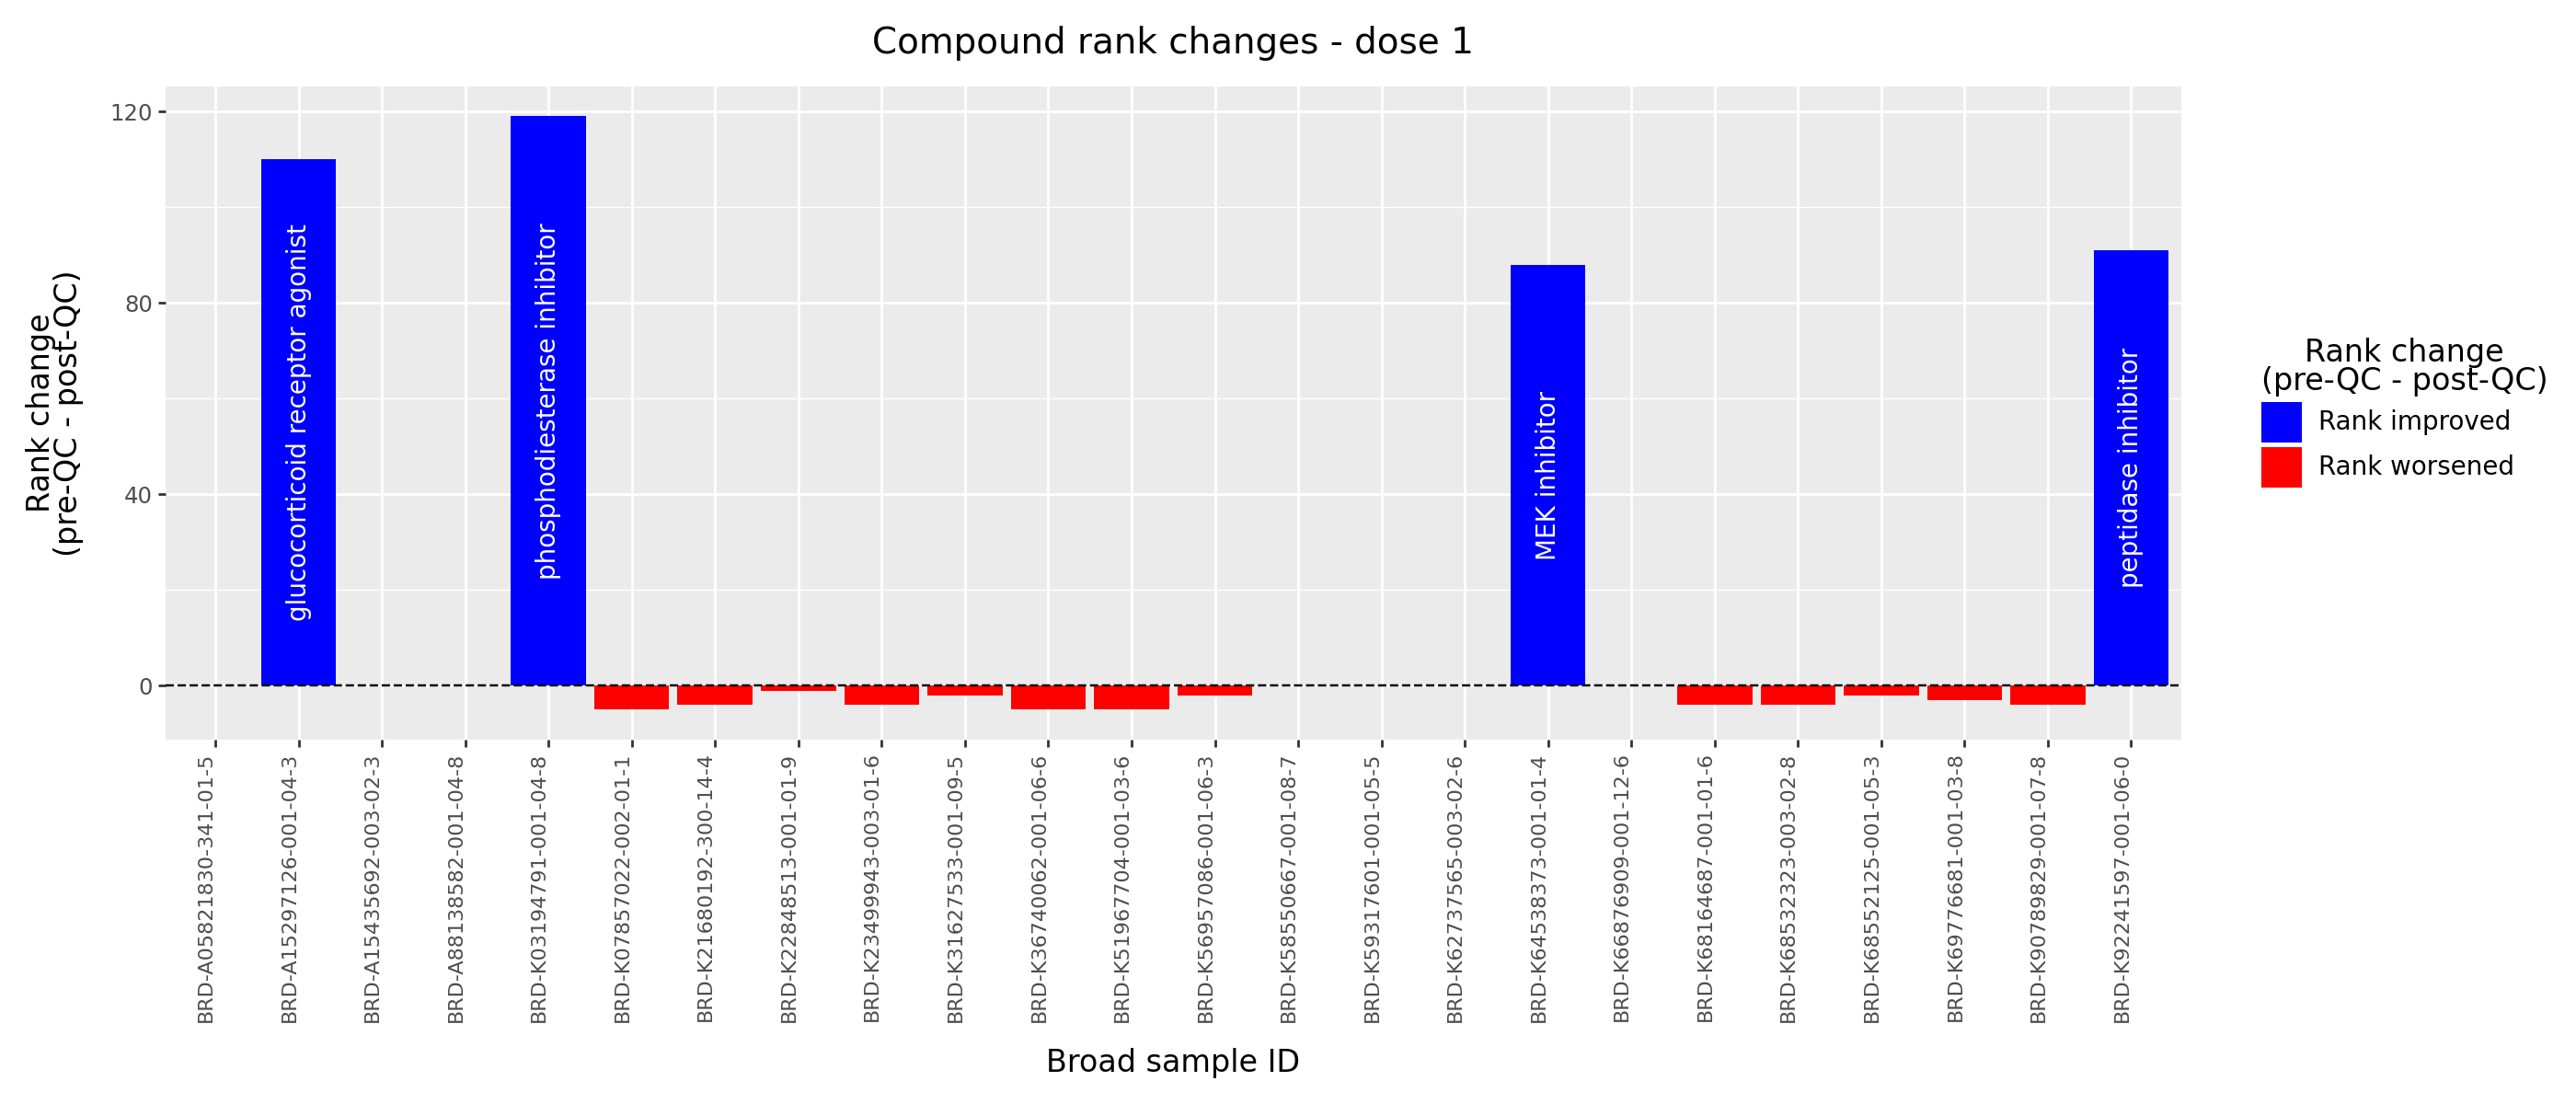

/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 14 x 6 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/rank_change_dose_2_bar_plot.png


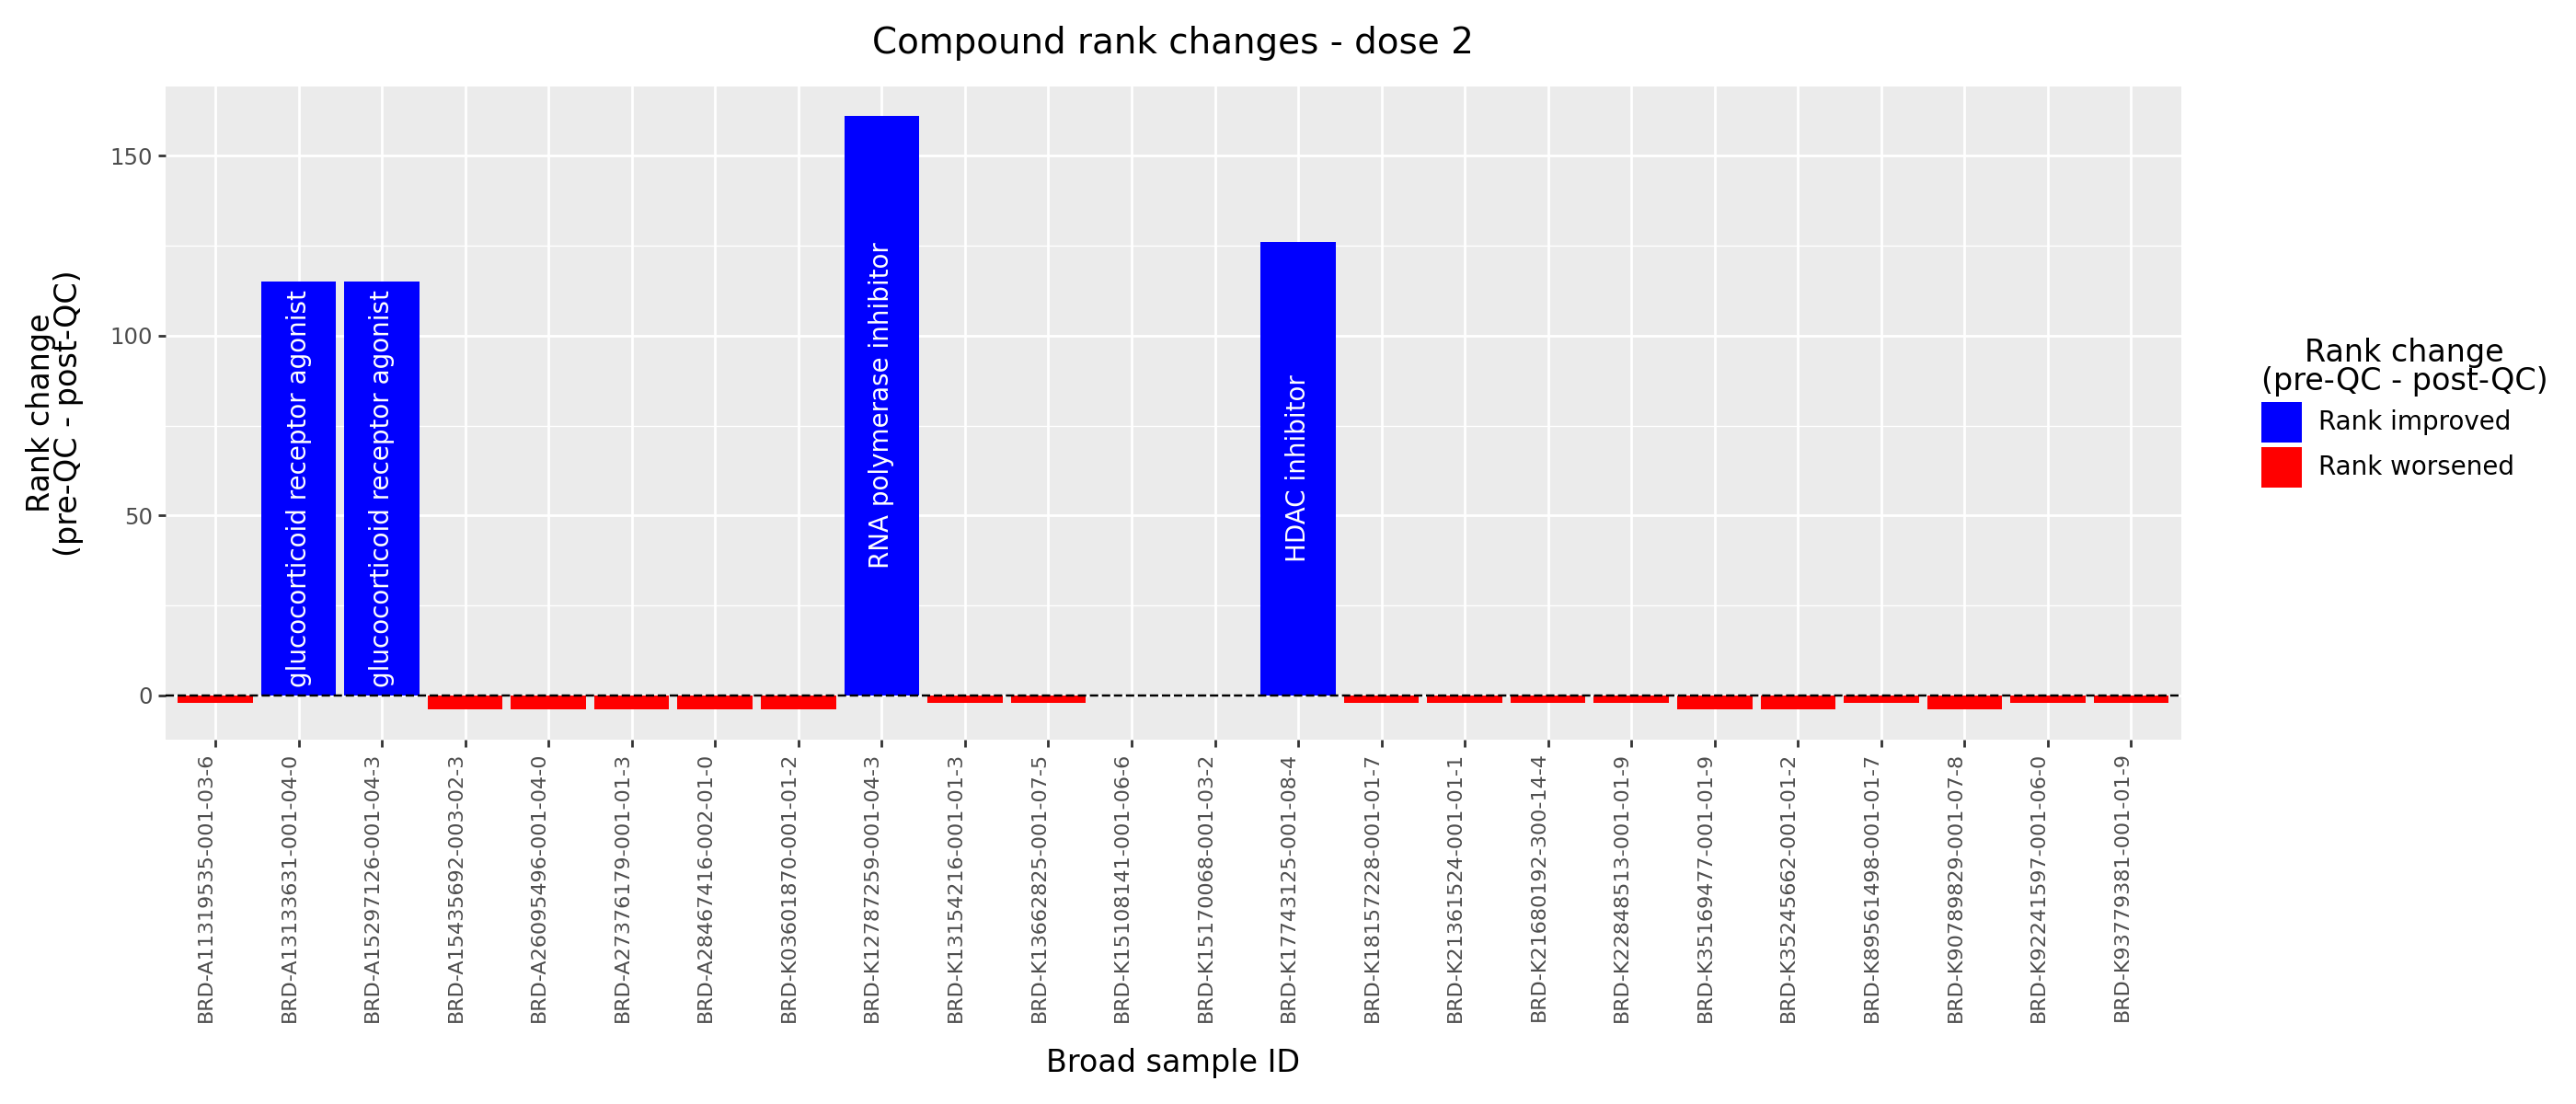

/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 14 x 6 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/rank_change_dose_4_bar_plot.png


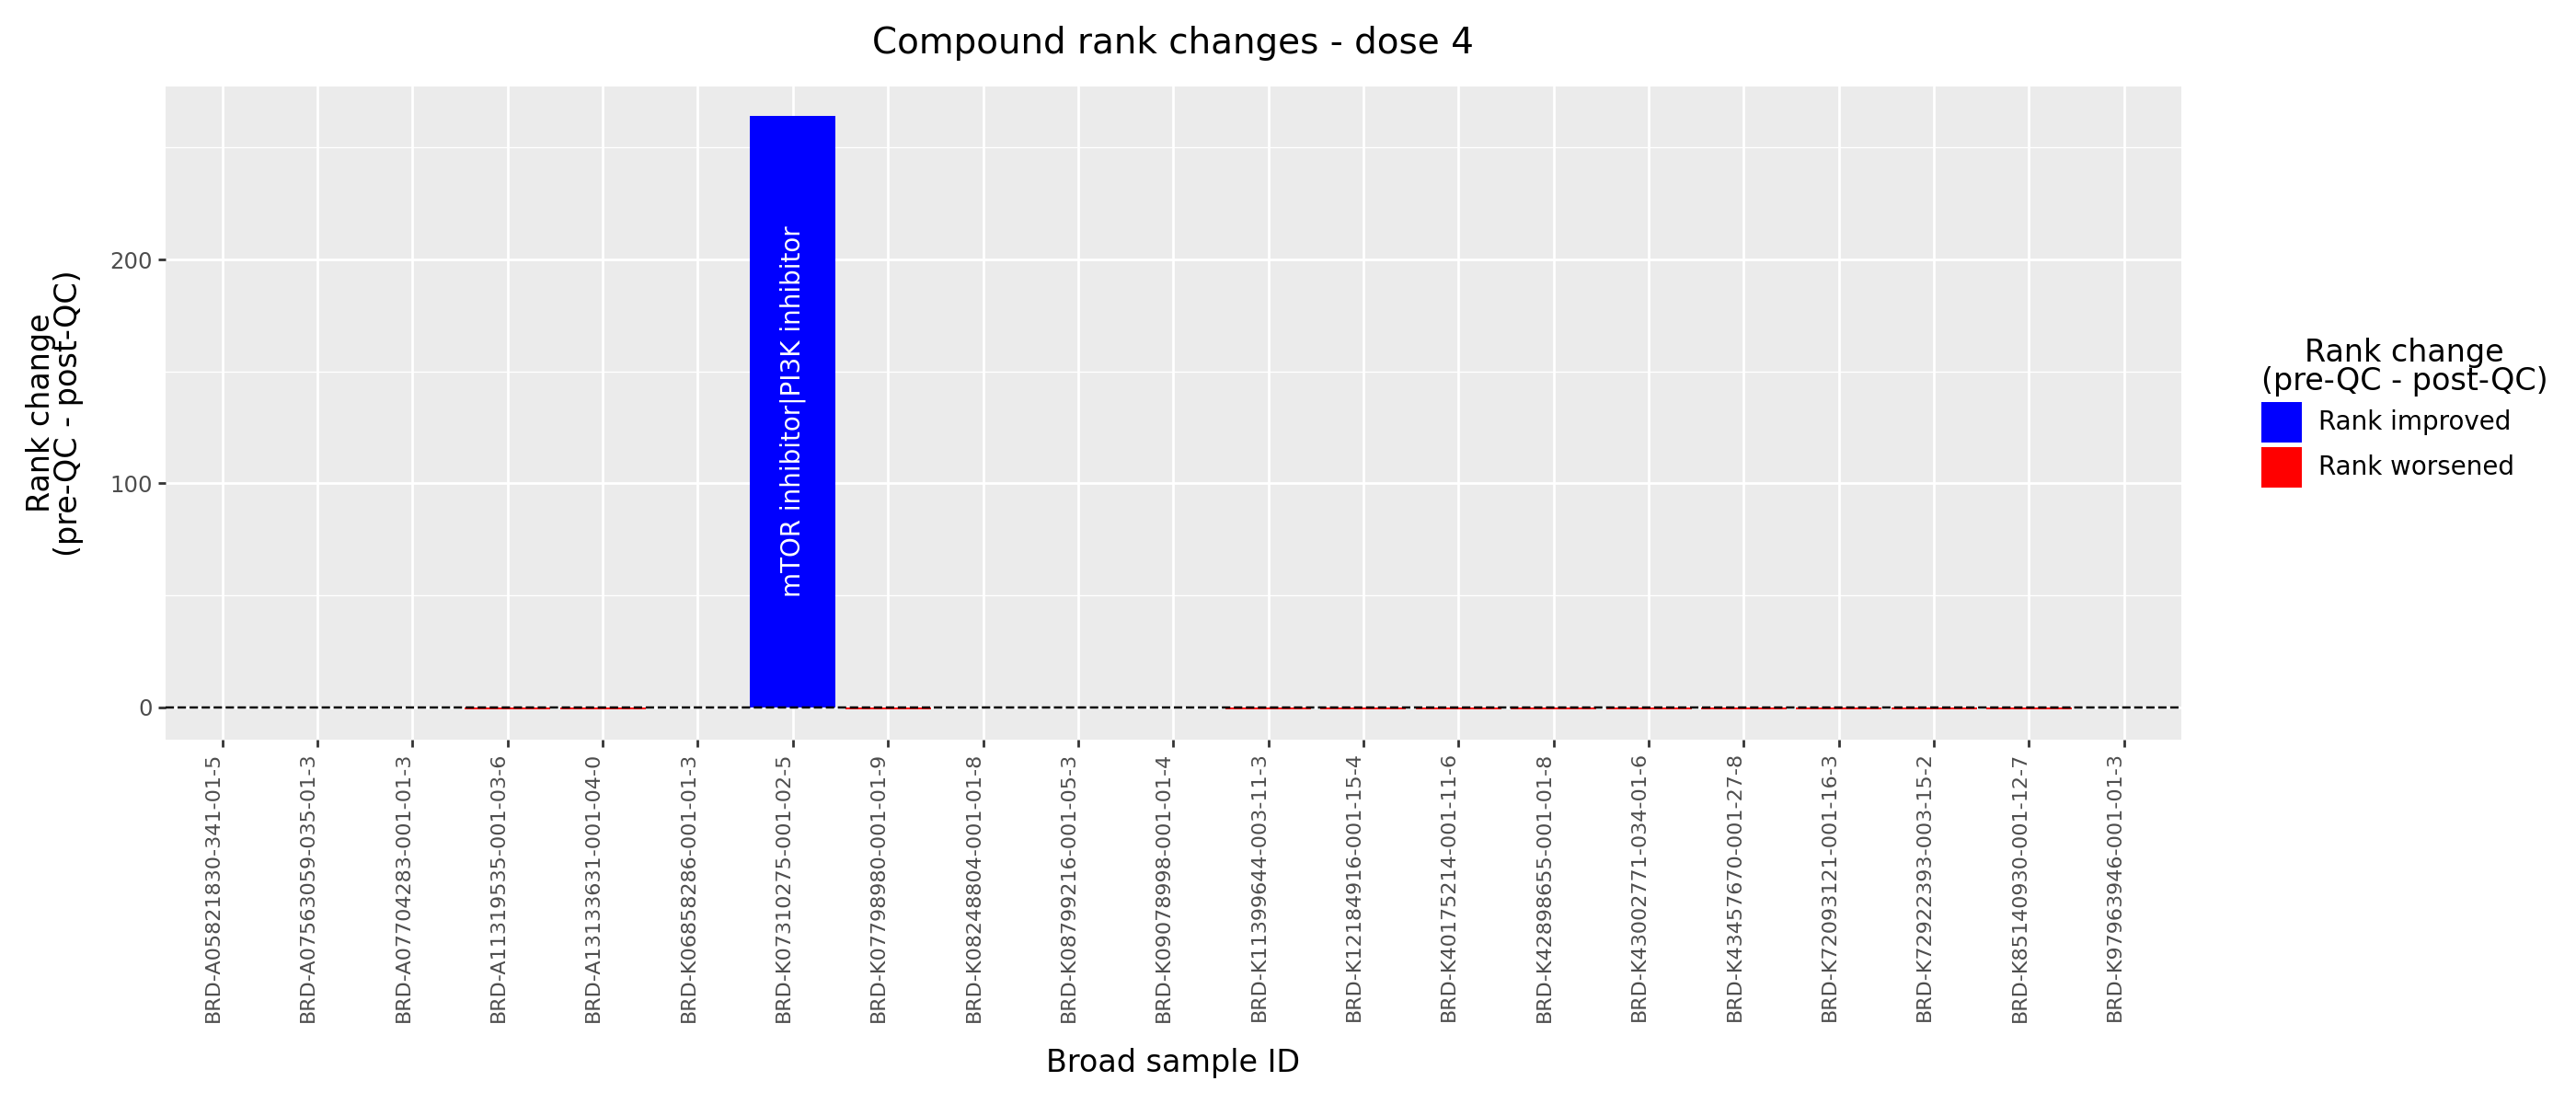

/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 14 x 6 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/rank_change_dose_6_bar_plot.png


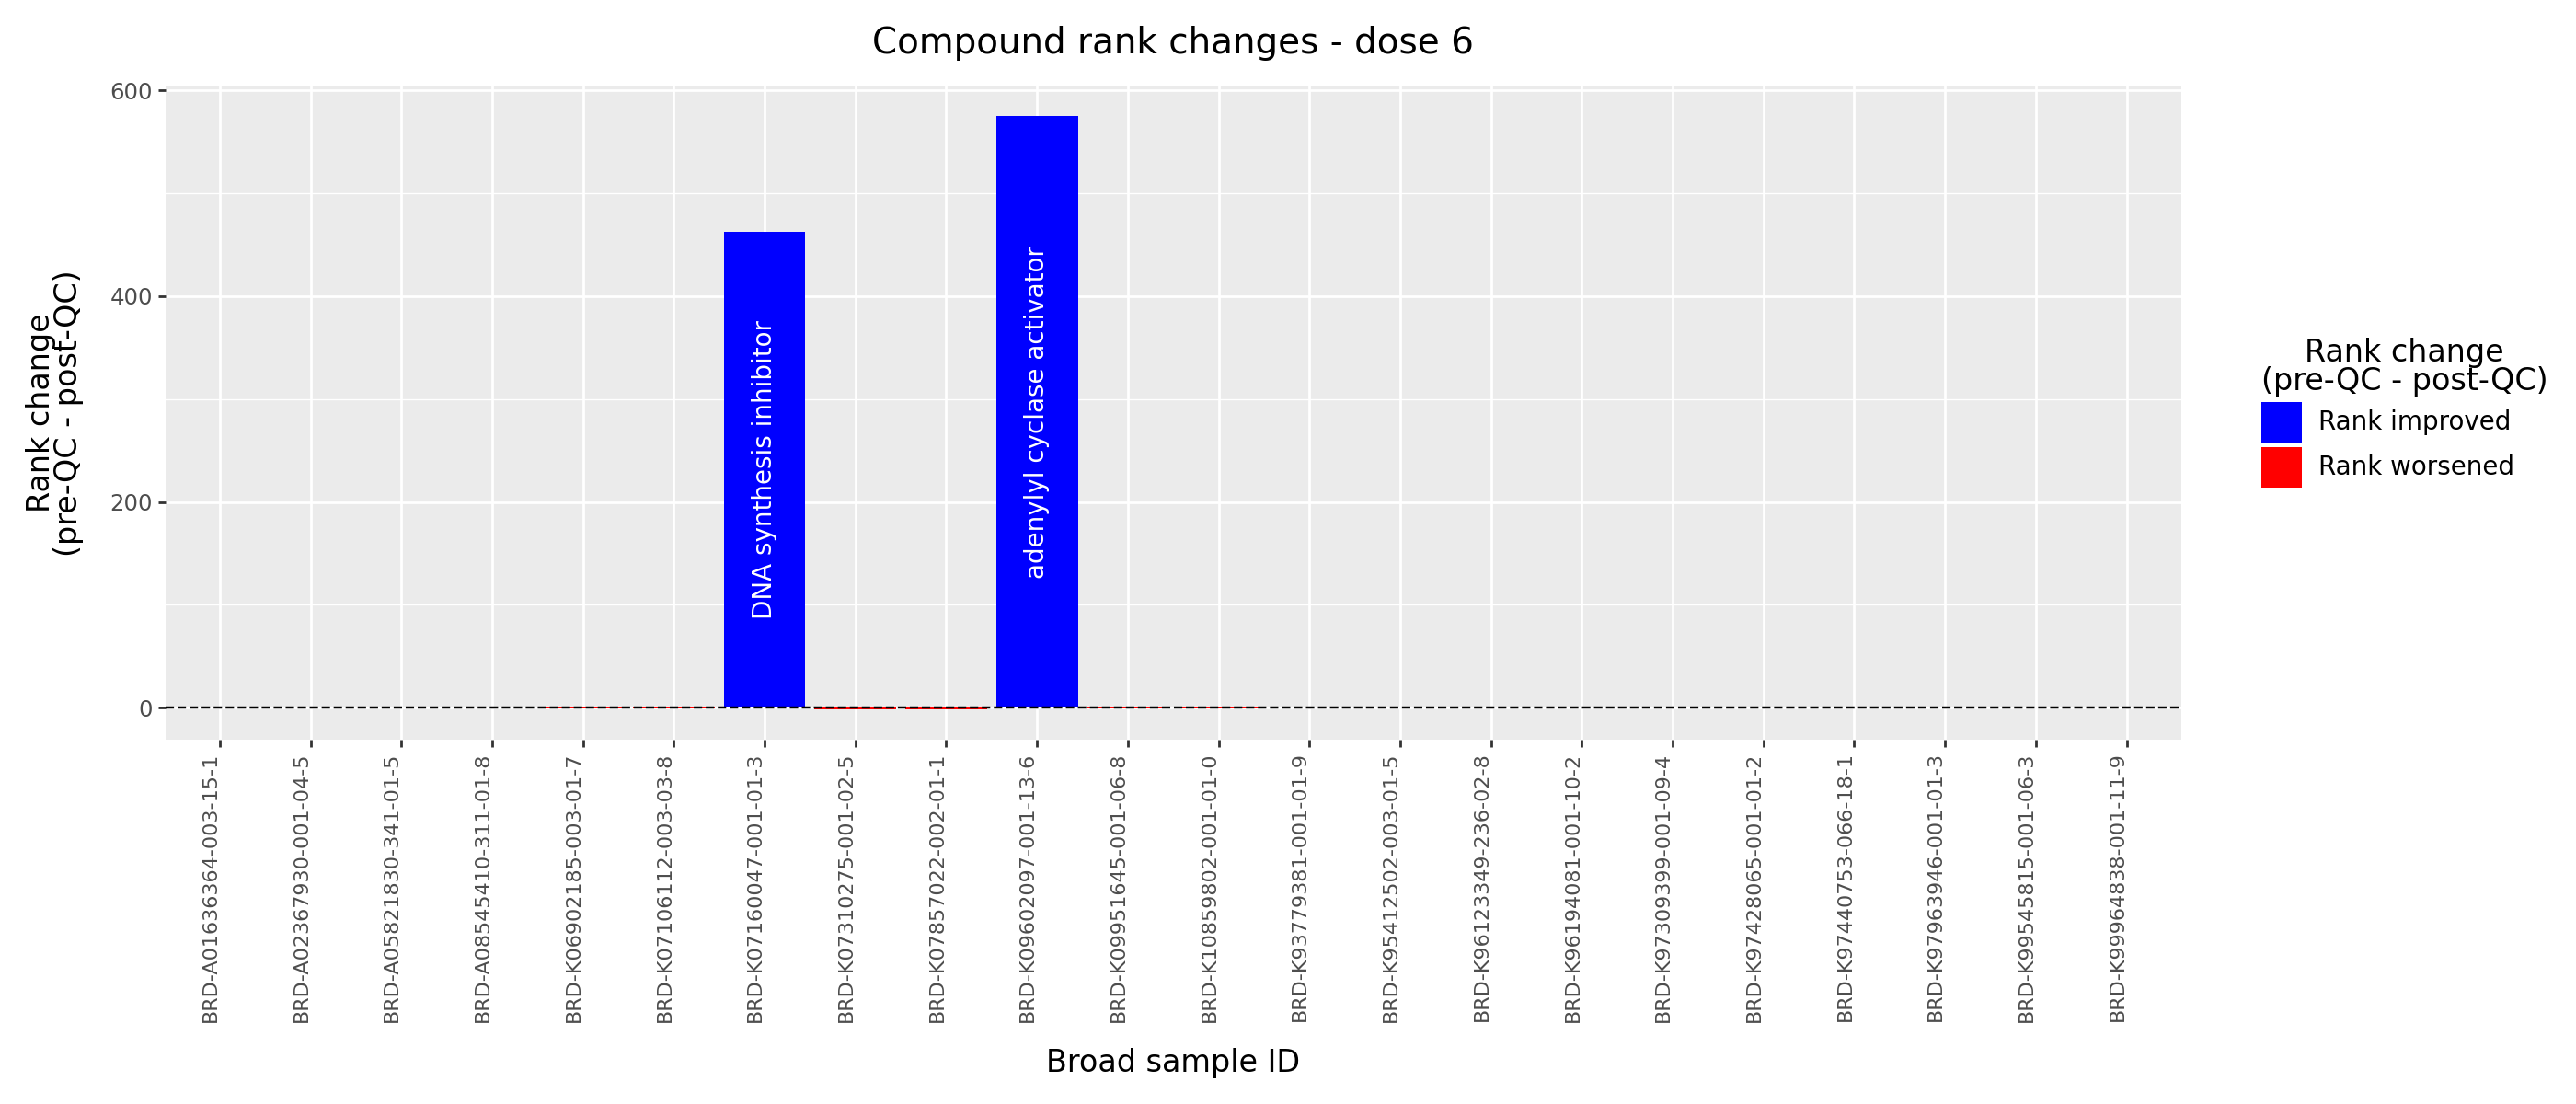

In [21]:
# Step 8: Plot per dose
for dose, df_dose in rank_change.groupby("Metadata_dose_recode"):

    if df_dose["rank_diff"].eq(0).all():
        continue

    # Create label position (inside bars)
    df_dose["label_y"] = df_dose["rank_diff"] * 0.5  # halfway inside bar

    p = (
        ggplot(df_dose, aes(x="Metadata_broad_sample", y="rank_diff", fill="color"))
        + geom_bar(stat="identity")
        # Add text labels for improved ranks (blue bars) with MoA
        + geom_text(
            data=df_dose[df_dose["color"] == "blue"],
            mapping=aes(
                x="Metadata_broad_sample",
                y="label_y",
                label="Metadata_moa"
            ),
            color="white",
            size=10,
            angle=90,
            ha="center",
            va="center"
        )

        + geom_hline(yintercept=0, color="black", linetype="dashed")
        + scale_fill_manual(
            name="Rank change\n(pre-QC - post-QC)",
            values={
                "blue": "blue",
                "red": "red"
            },
            labels=[
                "Rank improved",
                "Rank worsened"
            ],
        )
        + theme(
            figure_size=(14, 6),
            title=element_text(size=14),
            axis_text_x=element_text(rotation=90, hjust=1, size=8),
            axis_title_x=element_text(size=12),
            axis_title_y=element_text(size=12),
            legend_title=element_text(size=12),
            legend_text=element_text(size=10),
        )
        + labs(
            title=f"Compound rank changes - dose {dose}",
            x="Broad sample ID",
            y="Rank change\n(pre-QC - post-QC)",
        )
    )

    plot_path = f"figures/rank_change_dose_{dose}_bar_plot.png"
    p.save(plot_path, width=14, height=6, dpi=600)
    p.show()


In [22]:
# Filter for compounds where rank_diff > 0 (rank improved) for dose 1 and 2
improved_dose1 = rank_change[
    (rank_change["Metadata_dose_recode"] == 1) & (rank_change["rank_diff"] > 0)
]
improved_dose2 = rank_change[
    (rank_change["Metadata_dose_recode"] == 2)
    & (rank_change["rank_diff"] > 0)  # noqa: PLR2004
]
# Concatenate and get unique broad samples
# Only include broad sample as column
improved_compounds = pd.concat([improved_dose1, improved_dose2])[
    ["Metadata_broad_sample", "Metadata_dose_recode"]
]
broad_samples = improved_compounds["Metadata_broad_sample"].unique()

print(f"Broad samples of the {len(broad_samples)} unique compounds that went up in ranks from dose 1 and 2:")
for sample in broad_samples:
    print(sample)


Broad samples of the 7 unique compounds that went up in ranks from dose 1 and 2:
BRD-K92241597-001-06-0
BRD-K64538373-001-01-4
BRD-A15297126-001-04-3
BRD-K03194791-001-04-8
BRD-K17743125-001-08-4
BRD-A13133631-001-04-0
BRD-K12787259-001-04-3


In [23]:
# For each of the compounds at their respective dose, get the pre-QC rank
preqc_ranks = []
for _, row in improved_compounds.iterrows():
    sample = row["Metadata_broad_sample"]
    dose = row["Metadata_dose_recode"]
    # Find the preQC_rank for this sample and dose
    rank = merged_map_sorted.loc[
        (merged_map_sorted["Metadata_broad_sample"] == sample)
        & (merged_map_sorted["Metadata_dose_recode"] == dose),
        "preQC_rank",
    ]
    if not rank.empty:
        preqc_ranks.append(rank.values[0])

# Compute the average pre-QC rank
avg_preqc_rank = np.mean(preqc_ranks)
print(
    "Average pre-QC mAP rank for the compounds at their respective doses: "
    f"{avg_preqc_rank:.2f}"
)


Average pre-QC mAP rank for the compounds at their respective doses: 126.38


In [24]:
# Calculate total passed and failed cells per sample and dose
cell_counts = (
    post_qc_df_activity.groupby(["Metadata_broad_sample", "Metadata_dose_recode"])
    .agg(
        total_passed=("Metadata_sc_count_passed_qc", "sum"),
        total_failed=("Metadata_sc_count_failed_qc", "sum"),
    )
    .reset_index()
)

# Calculate total and proportion failed
cell_counts["total_cells"] = cell_counts["total_passed"] + cell_counts["total_failed"]
cell_counts["proportion_failed"] = (
    cell_counts["total_failed"] / cell_counts["total_cells"]
)

# Merge with improved_compounds
improved_compounds = improved_compounds.merge(
    cell_counts, on=["Metadata_broad_sample", "Metadata_dose_recode"], how="left"
)

# Add back Metadata_moa from post_qc_df_activity
moa_info = post_qc_df_activity[
    ["Metadata_broad_sample", "Metadata_moa"]
].drop_duplicates()
improved_compounds = improved_compounds.merge(
    moa_info, on="Metadata_broad_sample", how="left"
)

# Compute the average proportion failed across each compound in this list
avg_proportion_failed = improved_compounds["proportion_failed"].mean()
print(
    f"Average proportion of failed cells across the compounds: "
    f"{avg_proportion_failed:.4f}"
)

# Compute the average of the total passed across each compound in this list
avg_total_passed = improved_compounds["total_passed"].mean()
print(f"Average total passed cells across the compounds: {avg_total_passed:.0f}")

# Quantify the number of duplicate compounds (same broad sample at different doses)
duplicate_counts = improved_compounds["Metadata_broad_sample"].value_counts()
num_duplicates = (duplicate_counts > 1).sum()
print(
    "Number of duplicate compounds (same broad sample at different doses): "
    f"{num_duplicates}"
)

print(improved_compounds.shape)
improved_compounds.head(10)


Average proportion of failed cells across the compounds: 0.2766
Average total passed cells across the compounds: 6148
Number of duplicate compounds (same broad sample at different doses): 1
(8, 7)


,Metadata_broad_sample,Metadata_dose_recode,total_passed,total_failed,total_cells,proportion_failed,Metadata_moa
0,BRD-K92241597-001-06-0,1,8282,3979.0,12261.0,0.324525,peptidase inhibitor
1,BRD-K64538373-001-01-4,1,8399,3793.0,12192.0,0.311106,MEK inhibitor
2,BRD-A15297126-001-04-3,1,4074,1338.0,5412.0,0.247228,glucocorticoid receptor agonist
3,BRD-K03194791-001-04-8,1,5002,503.0,5505.0,0.091371,phosphodiesterase inhibitor
4,BRD-K17743125-001-08-4,2,8855,3625.0,12480.0,0.290465,HDAC inhibitor
5,BRD-A13133631-001-04-0,2,6316,2896.0,9212.0,0.314373,glucocorticoid receptor agonist
6,BRD-A15297126-001-04-3,2,4358,1545.0,5903.0,0.261731,glucocorticoid receptor agonist
7,BRD-K12787259-001-04-3,2,3897,2312.0,6209.0,0.372363,RNA polymerase inhibitor


## Only evaluate cosine similaity of the three compounds from the glucocorticoid receptor agonist MOA

In [25]:
targets_df = pd.DataFrame(
    [
        ("BRD-A15297126-001-04-3", 1),
        ("BRD-A15297126-001-04-3", 2),
        ("BRD-A13133631-001-04-0", 2),
    ],
    columns=["Metadata_broad_sample", "Metadata_dose_recode"],
)

plates_for_targets = (
    post_qc_df_activity.merge(
        targets_df,
        on=["Metadata_broad_sample", "Metadata_dose_recode"],
        how="inner",
    )
    .loc[:, ["Metadata_broad_sample", "Metadata_dose_recode", "Metadata_Plate", "Metadata_Well"]]
    .drop_duplicates()
    .sort_values(["Metadata_broad_sample", "Metadata_dose_recode", "Metadata_Plate", "Metadata_Well"])
)

plates_for_targets["Metadata_Plate"].unique()
plates_for_targets


,Metadata_broad_sample,Metadata_dose_recode,Metadata_Plate,Metadata_Well
3,BRD-A13133631-001-04-0,2,SQ00015194,G05
1,BRD-A13133631-001-04-0,2,SQ00015214,G05
0,BRD-A13133631-001-04-0,2,SQ00015215,G05
2,BRD-A13133631-001-04-0,2,SQ00015216,G05
4,BRD-A13133631-001-04-0,2,SQ00015217,G05
12,BRD-A15297126-001-04-3,1,SQ00015194,P12
8,BRD-A15297126-001-04-3,1,SQ00015214,P12
6,BRD-A15297126-001-04-3,1,SQ00015215,P12
10,BRD-A15297126-001-04-3,1,SQ00015216,P12
14,BRD-A15297126-001-04-3,1,SQ00015217,P12


## Find all wells across plates for these three compounds

In [26]:
target_moa = "glucocorticoid receptor agonist"
target_doses = [1, 2]
target_wells = pd.DataFrame(
    [
        ("SQ00015194", "G05"),
        ("SQ00015214", "G05"),
        ("SQ00015215", "G05"),
        ("SQ00015216", "G05"),
        ("SQ00015217", "G05"),
        ("SQ00015194", "P11"),
        ("SQ00015214", "P11"),
        ("SQ00015215", "P11"),
        ("SQ00015216", "P11"),
        ("SQ00015217", "P11"),
        ("SQ00015194", "P12"),
        ("SQ00015214", "P12"),
        ("SQ00015215", "P12"),
        ("SQ00015216", "P12"),
        ("SQ00015217", "P12"),
    ],
    columns=["Metadata_Plate", "Metadata_Well"],
)

metadata_cols = post_qc_df_activity.filter(regex="^Metadata").columns.tolist()
post_qc_numeric_cols = post_qc_df_activity.select_dtypes(include="number").columns
post_qc_profile_cols = [
    col
    for col in post_qc_numeric_cols
    if col not in metadata_cols and col != "failed_proportion"
]

target_profiles = (
    post_qc_df_activity.loc[
        post_qc_df_activity["Metadata_moa"].eq(target_moa)
        & post_qc_df_activity["Metadata_dose_recode"].isin(target_doses)
    ]
    .merge(target_wells, on=["Metadata_Plate", "Metadata_Well"], how="inner")
    .sort_values(
        ["Metadata_broad_sample", "Metadata_dose_recode", "Metadata_Plate", "Metadata_Well"]
    )
    .reset_index(drop=True)
)

target_profiles["well_id"] = (
    target_profiles["Metadata_Plate"] + ":" + target_profiles["Metadata_Well"]
)

target_profiles[
    ["Metadata_broad_sample", "Metadata_dose_recode", "Metadata_Plate", "Metadata_Well"]
].drop_duplicates()


,Metadata_broad_sample,Metadata_dose_recode,Metadata_Plate,Metadata_Well
0,BRD-A13133631-001-04-0,2,SQ00015194,G05
1,BRD-A13133631-001-04-0,2,SQ00015214,G05
2,BRD-A13133631-001-04-0,2,SQ00015215,G05
3,BRD-A13133631-001-04-0,2,SQ00015216,G05
4,BRD-A13133631-001-04-0,2,SQ00015217,G05
5,BRD-A15297126-001-04-3,1,SQ00015194,P12
6,BRD-A15297126-001-04-3,1,SQ00015214,P12
7,BRD-A15297126-001-04-3,1,SQ00015215,P12
8,BRD-A15297126-001-04-3,1,SQ00015216,P12
9,BRD-A15297126-001-04-3,1,SQ00015217,P12


## Compute pairwise cosine similairy scores per well for these compounds

In [27]:
profiles = target_profiles[post_qc_profile_cols].to_numpy(dtype=float)
profiles = np.nan_to_num(profiles, nan=0.0, posinf=0.0, neginf=0.0)
norms = np.linalg.norm(profiles, axis=1, keepdims=True)
normalized_profiles = np.divide(
    profiles,
    norms,
    out=np.zeros_like(profiles),
    where=norms > 0,
)
cosine_matrix = normalized_profiles @ normalized_profiles.T

pairwise_cosine_df = pd.DataFrame(
    cosine_matrix,
    index=target_profiles["well_id"],
    columns=target_profiles["well_id"],
)
pairwise_cosine_df


well_id,SQ00015194:G05,SQ00015214:G05,SQ00015215:G05,SQ00015216:G05,SQ00015217:G05,SQ00015194:P12,SQ00015214:P12,SQ00015215:P12,SQ00015216:P12,SQ00015217:P12,SQ00015194:P11,SQ00015214:P11,SQ00015215:P11,SQ00015216:P11,SQ00015217:P11
well_id,,,,,,,,,,,,,,,
SQ00015194:G05,1.000000,0.372966,0.272955,0.307996,0.329635,0.722360,0.195352,0.122387,0.231176,0.254682,0.745813,0.241772,0.203825,0.223575,0.307837
SQ00015214:G05,0.372966,1.000000,0.711960,0.766498,0.676590,0.370138,0.535032,0.516580,0.522543,0.563031,0.381274,0.657968,0.600349,0.532609,0.598917
SQ00015215:G05,0.272955,0.711960,1.000000,0.746696,0.694485,0.315846,0.459913,0.608702,0.534031,0.559867,0.276813,0.614781,0.717305,0.566590,0.657868
SQ00015216:G05,0.307996,0.766498,0.746696,1.000000,0.706987,0.349758,0.431475,0.517517,0.546431,0.540581,0.345329,0.563206,0.585499,0.556319,0.633616
SQ00015217:G05,0.329635,0.676590,0.694485,0.706987,1.000000,0.344993,0.424614,0.509807,0.478229,0.681311,0.352445,0.540099,0.583597,0.496723,0.776485
SQ00015194:P12,0.722360,0.370138,0.315846,0.349758,0.344993,1.000000,0.221648,0.171900,0.240883,0.293719,0.778018,0.301941,0.252735,0.270956,0.337067
SQ00015214:P12,0.195352,0.535032,0.459913,0.431475,0.424614,0.221648,1.000000,0.622296,0.649960,0.561497,0.246566,0.710876,0.618566,0.634436,0.540536
SQ00015215:P12,0.122387,0.516580,0.608702,0.517517,0.509807,0.171900,0.622296,1.000000,0.710410,0.625658,0.178363,0.678546,0.798195,0.688737,0.639581
SQ00015216:P12,0.231176,0.522543,0.534031,0.546431,0.478229,0.240883,0.649960,0.710410,1.000000,0.587818,0.273310,0.694172,0.710896,0.803728,0.605951


## Generate complex heatmap comparing cosine similarity scores

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting HeatmapAnnotations
Plotting HeatmapAnnotations
Plotting legends..


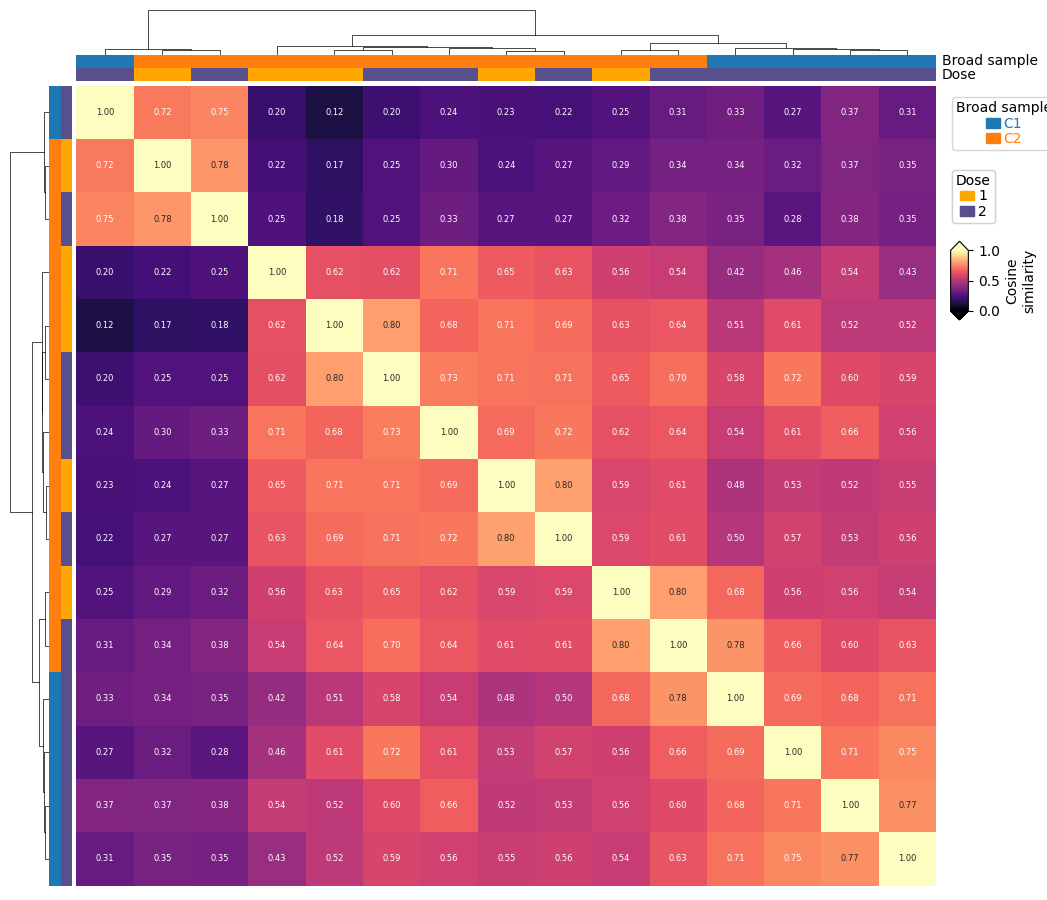

In [28]:
annotation_df = target_profiles[
    ["well_id", "Metadata_broad_sample", "Metadata_dose_recode"]
].drop_duplicates()

annotation_df = annotation_df.set_index("well_id").loc[pairwise_cosine_df.index]

mapping = {
    "BRD-A15297126-001-04-3": "C2",
    "BRD-A13133631-001-04-0": "C1",
}

annotation_df["Compound_short"] = annotation_df["Metadata_broad_sample"].map(mapping)

sample_colors = {
    "C1": "#1f77b4",
    "C2": "#ff7f0e",
}

dose_colors = {1: "#ffa600", 2: "#58508d"}

row_anno = HeatmapAnnotation(
    **{
        "": anno_simple(
            annotation_df["Compound_short"],
            colors=sample_colors,
            legend=False,
        ),
        " ": anno_simple(
            annotation_df["Metadata_dose_recode"],
            colors=dose_colors,
            legend=False,
        ),
    },
    axis=0,
)

col_anno = HeatmapAnnotation(
    **{
        "Broad sample": anno_simple(
            annotation_df["Compound_short"],
            colors=sample_colors,
            legend=True,
        ),
        "Dose": anno_simple(
            annotation_df["Metadata_dose_recode"],
            colors=dose_colors,
            legend=True,
        ),
    },
    axis=1,
)

plt.figure(figsize=(12, 10))

ClusterMapPlotter(
    data=pairwise_cosine_df,
    top_annotation=col_anno,
    left_annotation=row_anno,
    cmap="magma",
    vmin=0,
    vmax=1,
    row_cluster=True,
    col_cluster=True,
    row_dendrogram=True,
    col_dendrogram=True,
    show_rownames=False,
    show_colnames=False,
    xticklabels_kws={"labelrotation": 90, "labelsize": 10},
    yticklabels_kws={"labelsize": 10},
    label="Cosine\nsimilarity",
    legend_side="right",
    legend_anchor="ax_heatmap",
    legend_width=5,
    legend_hpad=2,
    legend_vgap=5,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 6},
)

plt.savefig(
    "./figures/heatmap_GCCRA_well_cosine_similarity.png",
    bbox_inches="tight",
    dpi=600,
    pad_inches=0.5,
)

plt.show()
